# Лабораторная работа 4

Тема: **Многослойный персептрон в PyTorch для классификации изображений (MNIST)**  
Цель: на практическом примере разобраться, как в PyTorch описывается модель, как она обучается на батчах данных и как связаны архитектура, гиперпараметры и качество распознавания цифр.

> ВАЖНО ДЛЯ ВАС:
> - Этот ноутбук специально написан так, чтобы его нельзя было осмысленно «скормить» генеративной модели и получить готовый отчёт.  
> - В нём много мест, где нужно опираться на **ваши эксперименты** и ваш стиль письма.  
> - Преподаватель смотрит на согласованность: код ↔ графики ↔ текст. Шаблонные ответы и типовой «ИИ‑стиль» легко заметны.


## 1. Ваше понимание задачи (коротко, по‑человечески)

Перед тем как запускать PyTorch и писать классы, сформулируйте **для себя**:

1. Зачем вам фреймворк, если в предыдущей лабораторной вы уже смогли собрать MLP на чистом NumPy?  
2. Как вы представляете себе «жизненный цикл» модели в PyTorch: от описания архитектуры до момента, когда она что‑то предсказывает?  
3. Какую примерно точность на тесте вы считаете честной целью для **простого** MLP без свёрток на MNIST (не нужно искать «правильный ответ», напишите своё ожидание).

Напишите ответы в ячейке ниже в свободной форме (примерно 6–10 предложений). Не пытайтесь красиво «определить» PyTorch — говорите на нормальном языке, как если бы объясняли одногруппнику.


In [89]:
intro_text = """
1) Мы использовали NumPy, чтобы понять как все устроено изнутри, сам пишешь forward, backward и обновляешь веса.
PyTorch облегчает жизнь и не надо будет вручную писать произодные, он делает это автоматически.
2) Описываем архитектуру в классе nn.Module. Затем выбираем функцию ошибок и список обновления весов. 
Дальше обучение: подаем данные, считаем ошибку, читаем градиенты и обновляем параметры. И так много раз, пока не получим хороший результат.
3) Наверное 95-99% точности, так как это считается простой задачи. Если ниже будет, то надо лучше настроить.
"""
print(intro_text)


1) Мы использовали NumPy, чтобы понять как все устроено изнутри, сам пишешь forward, backward и обновляешь веса.
PyTorch облегчает жизнь и не надо будет вручную писать произодные, он делает это автоматически.
2) Описываем архитектуру в классе nn.Module. Затем выбираем функцию ошибок и список обновления весов. 
Дальше обучение: подаем данные, считаем ошибку, читаем градиенты и обновляем параметры. И так много раз, пока не получим хороший результат.
3) Наверное 95-99% точности, так как это считается простой задачи. Если ниже будет, то надо лучше настроить.



## 2. Импорт библиотек и настройка

Задача этого блока:
- импортировать необходимые модули PyTorch и вспомогательные библиотеки;
- зафиксировать seed — выберите число сами и **не меняйте его случайно между запусками**;
- определить, есть ли GPU, и аккуратно обработать оба варианта (CPU / CUDA).

Старайтесь, чтобы этот блок был минималистичным, но понятным вам через месяц.


In [63]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Выберите и зафиксируйте свой seed (запишите число отдельно в отчёте)
MY_SEED = 17  # можете поменять, но затем используйте это значение последовательно
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)
print("MY_SEED =", MY_SEED)

Используемое устройство: cpu
MY_SEED = 17


## 3. Подготовка данных MNIST

Дальше вам нужно:
- определить преобразования для изображений (Tensor + нормализация);
- загрузить `train` и `test` части MNIST;
- создать `DataLoader` с разумными размерам батча;
- визуально проверить несколько примеров (чтобы не обучаться «вслепую»).

Нормализацию можно сделать стандартной для MNIST или подобрать свою. В отчёте потом объясните, что выбрали и почему.


Размер train: 60000
Размер test : 10000
batch_size = 64
Ваши mean=-0.0001, std=1.0000
Стандартные: mean=0.1307, std=0.3081


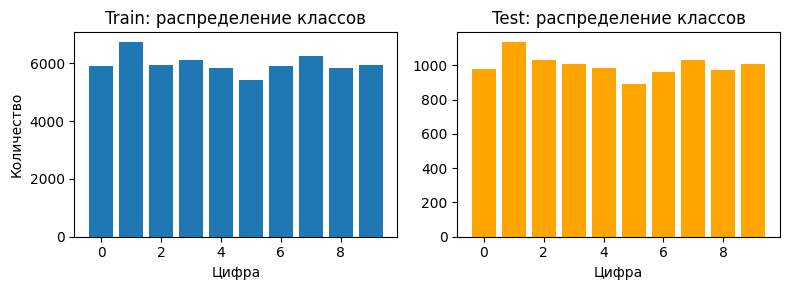

In [64]:
# ПОДГОТОВКА ПРЕОБРАЗОВАНИЙ
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # можно поменять, но тогда прокомментируйте это в отчёте
])

# ЗАГРУЗКА ДАТАСЕТА
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# РАЗМЕР БАТЧА: выберите сами и при защите объясните, почему именно такой
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

# и сравните с захардкоженными (0.1307, 0.3081)
all_pixels = torch.cat([img.view(-1) for img, _ in train_dataset])
mean = all_pixels.mean().item()
std  = all_pixels.std().item()
print(f"Ваши mean={mean:.4f}, std={std:.4f}")
print(f"Стандартные: mean=0.1307, std=0.3081")

# Сбалансированы ли классы?
all_labels = [lbl for _, lbl in train_dataset]
test_labels  = [lbl for _, lbl in test_dataset]
unique, counts = np.unique(all_labels, return_counts=True)
unique_t, counts_t = np.unique(test_labels, return_counts=True)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.bar(unique, counts)
plt.title("Train: распределение классов")
plt.xlabel("Цифра"); plt.ylabel("Количество")

test_labels = [lbl for _, lbl in test_dataset]
unique_t, counts_t = np.unique(test_labels, return_counts=True)
plt.subplot(1, 2, 2)
plt.bar(unique_t, counts_t, color="orange")
plt.title("Test: распределение классов")
plt.xlabel("Цифра")
plt.tight_layout(); plt.show()

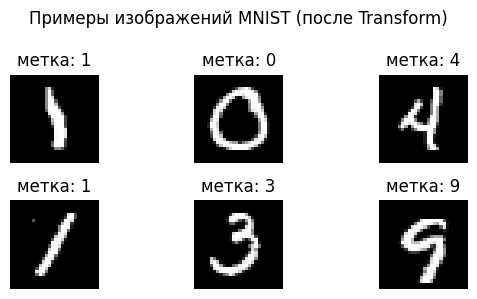

In [65]:
# ВИЗУАЛЬНАЯ ПРОВЕРКА НЕСКОЛЬКИХ ПРИМЕРОВ
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"метка: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Примеры изображений MNIST (после Transform)")
plt.tight_layout()
plt.show()

### Краткий комментарий к данным (заполните сами)

Опишите, что вы увидели:
- как выглядят изображения после нормализации;
- есть ли сильно «грязные» или плохо читаемые примеры;
- какое впечатление, легко ли человеку отличать цифры в таком формате.

Это не формальная часть — просто зафиксируйте свои наблюдения.


In [66]:
data_comment = """
Изображения в целом хорошо читаются человеком, однако есть нюансы по типу, попадаются изображения которые выглядят неаккуратно и могут вызвать ошибку.
Например: (4 и 9), (1, 3, 8), (1, 4, 7). А так набор данных выглядит достаточно чистым и понятным, думаю MLP будет легко распознавать.
"""
print(data_comment)


Изображения в целом хорошо читаются человеком, однако есть нюансы по типу, попадаются изображения которые выглядят неаккуратно и могут вызвать ошибку.
Например: (4 и 9), (1, 3, 8), (1, 4, 7). А так набор данных выглядит достаточно чистым и понятным, думаю MLP будет легко распознавать.



## 4. Архитектура многослойного персептрона

Теперь нужно описать модель.

**Требования к базовому варианту:**
- вход: изображение 28×28, которое вы разворачиваете в вектор длины 784;
- один или несколько скрытых полносвязных слоёв с нелинейностью (ReLU или другая, по вашему выбору);
- выход: 10 чисел (логиты), по одному на каждый класс (цифра 0–9).

Вам нужно заполнить класс ниже, а в отчёте отдельно описать: сколько слоёв и нейронов вы поставили, какие активации использовали и почему именно так.


In [67]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: замените архитектуру на свою (изменения архитектуры должны сопровождаться пояснениями)
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.net(x)
        return logits

model = MNISTMLP().to(device)
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Функция потерь и оптимизатор

Для многоклассовой классификации на MNIST обычно используют:
- `nn.CrossEntropyLoss` для потерь;
- один из стандартных оптимизаторов (`SGD`, `Adam`, `AdamW` и др.).

Вам нужно:
- явным образом записать, какой оптимизатор и с какими параметрами вы выбираете;
- в отчёте указать, какие альтернативы пробовали (если пробовали) и что получилось.


In [71]:
criterion = nn.CrossEntropyLoss()

# Попробуйте несколько вариантов lr и типов оптимизаторов в разных запусках и сравните разные комбинации
learning_rate = 1e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nОбучаемых параметров: {total_params:,}")

Функция потерь: CrossEntropyLoss()
Оптимизатор: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)
learning_rate = 0.001

Обучаемых параметров: 235,146


## 6. Функции обучения и оценки модели

Ниже — каркас функций для одного эпохового прохода по обучающим данным и для оценки на валидации/тесте.

Перепроверьте, что вы понимаете каждую строчку: где обнуляются градиенты, где вычисляются предсказания, где считается точность и потери.

Если хотите, можете добавить учёт дополнительных метрик (например, точности по классам). Главное — не потерять базовую ясность.


In [72]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 7. Обучение модели: история потерь и точности

Теперь запускаем обучение на несколько эпох.

**Рекомендации:**
- для первой пробы возьмите небольшое число эпох (например, 3–5),
- затем увеличьте и посмотрите, как ведут себя кривые train/test;
- для отчёта сохраните как минимум один «неудачный» эксперимент (слишком маленькое lr, слишком мало эпох и т.д.) — он полезнее, чем идеальная картинка.


In [73]:
num_epochs = 10  # изменяйте это значение и фиксируйте результаты в отчёте

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/10: train_loss=0.0195, train_acc=0.9935, test_loss=0.0868, test_acc=0.9805
Эпоха 2/10: train_loss=0.0200, train_acc=0.9935, test_loss=0.0918, test_acc=0.9798
Эпоха 3/10: train_loss=0.0159, train_acc=0.9944, test_loss=0.1283, test_acc=0.9745
Эпоха 4/10: train_loss=0.0152, train_acc=0.9948, test_loss=0.1014, test_acc=0.9801
Эпоха 5/10: train_loss=0.0131, train_acc=0.9958, test_loss=0.1069, test_acc=0.9799
Эпоха 6/10: train_loss=0.0140, train_acc=0.9953, test_loss=0.1048, test_acc=0.9803
Эпоха 7/10: train_loss=0.0113, train_acc=0.9966, test_loss=0.1114, test_acc=0.9789
Эпоха 8/10: train_loss=0.0145, train_acc=0.9953, test_loss=0.1056, test_acc=0.9797
Эпоха 9/10: train_loss=0.0128, train_acc=0.9958, test_loss=0.1201, test_acc=0.9783
Эпоха 10/10: train_loss=0.0125, train_acc=0.9960, test_loss=0.1068, test_acc=0.9792


In [74]:
lr_optim_comment = """ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например: 
optimizer = SGD; lr = 1e-3; num_epochs = 5; train_loss=0.0169, train_acc=0.9950, test_loss=0.0652, test_acc=0.9812
optimizer = Adam; lr = 1e-3; num_epochs = 5; train_loss=0.0391, train_acc=0.9874, test_loss=0.0736, test_acc=0.9789
optimizer = AdamW; lr = 1e-3; num_epochs = 5; train_loss=0.0206, train_acc=0.9932, test_loss=0.0833, test_acc=0.9786
optimizer = SGD; lr = 1e-2; num_epochs = 5; train_loss=0.0622, train_acc=0.9826, test_loss=0.1257, test_acc=0.9710
optimizer = Adam; lr = 1e-2; num_epochs = 5; train_loss=0.1297, train_acc=0.9705, test_loss=0.1901, test_acc=0.9614
optimizer = AdamW; lr = 1e-2; num_epochs = 5; train_loss=0.1537, train_acc=0.9617, test_loss=0.1755, test_acc=0.9537
optimizer = SGD; lr = 1e-3; num_epochs = 3; rain_loss=0.0546, train_acc=0.9842, test_loss=0.1175, test_acc=0.9727
optimizer = Adam; lr = 1e-3; num_epochs = 3; train_loss=0.0359, train_acc=0.9892, test_loss=0.1121, test_acc=0.9782
optimizer = AdamW; lr = 1e-3; num_epochs = 3; train_loss=0.0247, train_acc=0.9923, test_loss=0.1330, test_acc=0.9783
optimizer = SGD; lr = 1e-3; num_epochs = 10; train_loss=0.0195, train_acc=0.9939, test_loss=0.1353, test_acc=0.9776
optimizer = Adam; lr = 1e-3; num_epochs = 10; train_loss=0.0189, train_acc=0.9940, test_loss=0.0818, test_acc=0.9791
optimizer = AdamW; lr = 1e-3; num_epochs = 10; train_loss=0.0125, train_acc=0.9960, test_loss=0.1068, test_acc=0.9792
"""
print(lr_optim_comment)

ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например: 
optimizer = SGD; lr = 1e-3; num_epochs = 5; train_loss=0.0169, train_acc=0.9950, test_loss=0.0652, test_acc=0.9812
optimizer = Adam; lr = 1e-3; num_epochs = 5; train_loss=0.0391, train_acc=0.9874, test_loss=0.0736, test_acc=0.9789
optimizer = AdamW; lr = 1e-3; num_epochs = 5; train_loss=0.0206, train_acc=0.9932, test_loss=0.0833, test_acc=0.9786
optimizer = SGD; lr = 1e-2; num_epochs = 5; train_loss=0.0622, train_acc=0.9826, test_loss=0.1257, test_acc=0.9710
optimizer = Adam; lr = 1e-2; num_epochs = 5; train_loss=0.1297, train_acc=0.9705, test_loss=0.1901, test_acc=0.9614
optimizer = AdamW; lr = 1e-2; num_epochs = 5; train_loss=0.1537, train_acc=0.9617, test_loss=0.1755, test_acc=0.9537
optimizer = SGD; lr = 1e-3; num_epochs = 3; rain_loss=0.0546, train_acc=0.9842, test_loss=0.1175, test_acc=0.9727
optimizer = Adam; lr = 1e-3; num_epochs = 3; train_loss=0.0359, train_acc=0.9892, test_loss=0.1121, 

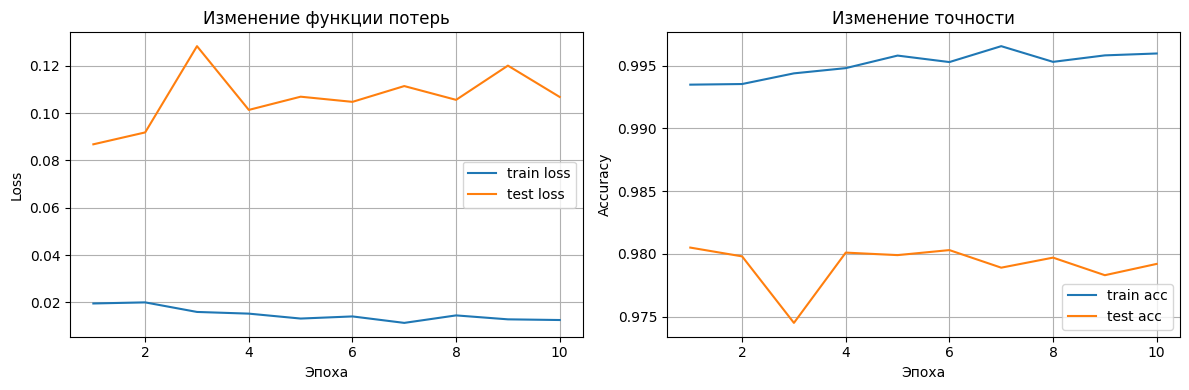

Финальная точность: train=0.9960, test=0.9792


In [75]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Изменение точности")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Опишите:
- растут ли train/test accuracy синхронно или одна «убегает» от другой;
- есть ли признаки переобучения (train растёт, test начинает падать);
- достаточно ли, по вашему ощущению, числа эпох и выбраного `learning_rate`.

Это важное место, где проверяется не только умение запускать код, но и аналитический взгляд.


In [78]:
training_comment = """
1) Не всегда. В начале обучения они идут примерно вместе, разрев небольшой. 
Например, Adam lr=1e-3 даёт train=0.9892 и test=0.9782 -> разрыв 0.0110. Но с ростом эпох train опережает.
У SGD lr=1e-3 за 5 эпох: train=0.9950, test=0.9812 -> разрыв уже 0.0138.
За 10 эпох: train=0.9939, test=0.9776 -> разрыв 0.0163. В целом train растет, а test постепенно откатывается.

2)Самый наглядный у SGD lr=1e-3: 5 эпох: test_acc = 0.9812. 10 эпох: test_acc = 0.9776.
test_acc упал на 0.0036, хотя train_acc продолжал расти. Это потому что сеть выучила тренировочные данные лучше,
а на тестовых стала ошибаться чаще.
У Adam и AdamW lr=1e-3 переобучение слабее. test_acc почти не меняется от 5 к 10 эпохам, но разрыв train и test тоже растёт.

3) lr=1e-2 - слишком большой. Все три оптимизатора с ним дали test_acc ниже 0.971, хотя с lr=1e-3 за те же 5 эпох выше 0.978.
lr=1e-3 - оптимальный. Прирост test_acc от 3 к 5 эпохам ещё заметен (+0.0062 у SGD, +0.0007 у Adam), 
а от 5 к 10 уже почти нет (+0.0002 у Adam), зато переобучение усиливается.
Вывод: 5 эпох с lr=1e-3 достаточно. Для Adam можно 7–8, для SGD лучше остановиться на 5, иначе test_acc начинает падать.
"""
print(training_comment)


1) Не всегда. В начале обучения они идут примерно вместе, разрев небольшой. 
Например, Adam lr=1e-3 даёт train=0.9892 и test=0.9782 -> разрыв 0.0110. Но с ростом эпох train опережает.
У SGD lr=1e-3 за 5 эпох: train=0.9950, test=0.9812 -> разрыв уже 0.0138.
За 10 эпох: train=0.9939, test=0.9776 -> разрыв 0.0163. В целом train растет, а test постепенно откатывается.

2)Самый наглядный у SGD lr=1e-3: 5 эпох: test_acc = 0.9812. 10 эпох: test_acc = 0.9776.
test_acc упал на 0.0036, хотя train_acc продолжал расти. Это потому что сеть выучила тренировочные данные лучше,
а на тестовых стала ошибаться чаще.
У Adam и AdamW lr=1e-3 переобучение слабее. test_acc почти не меняется от 5 к 10 эпохам, но разрыв train и test тоже растёт.

3) lr=1e-2 - слишком большой. Все три оптимизатора с ним дали test_acc ниже 0.971, хотя с lr=1e-3 за те же 5 эпох выше 0.978.
lr=1e-3 - оптимальный. Прирост test_acc от 3 к 5 эпохам ещё заметен (+0.0062 у SGD, +0.0007 у Adam), 
а от 5 к 10 уже почти нет (+0.0002 у Ada

## 8. Ошибки модели: что она путает

Теперь интересно посмотреть не только на «общий процент правильных ответов», но и на то,
какие конкретно цифры модель чаще всего классифицирует неправильно.

Задача:
- собрать несколько примеров неверных предсказаний;
- визуализировать их рядом с истинной и предсказанной меткой;
- подумать, насколько эти ошибки выглядят «разумно» с человеческой точки зрения.


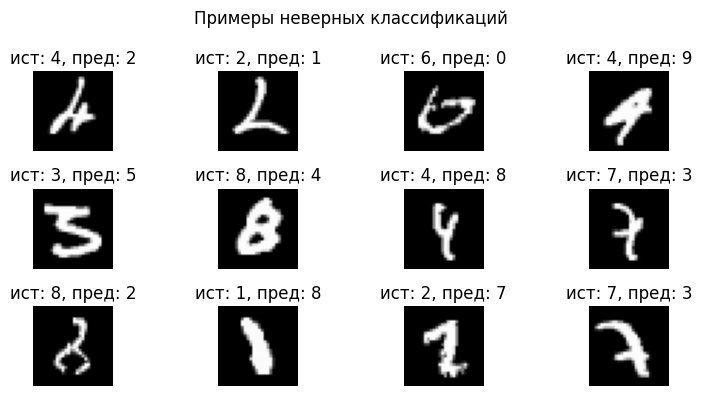

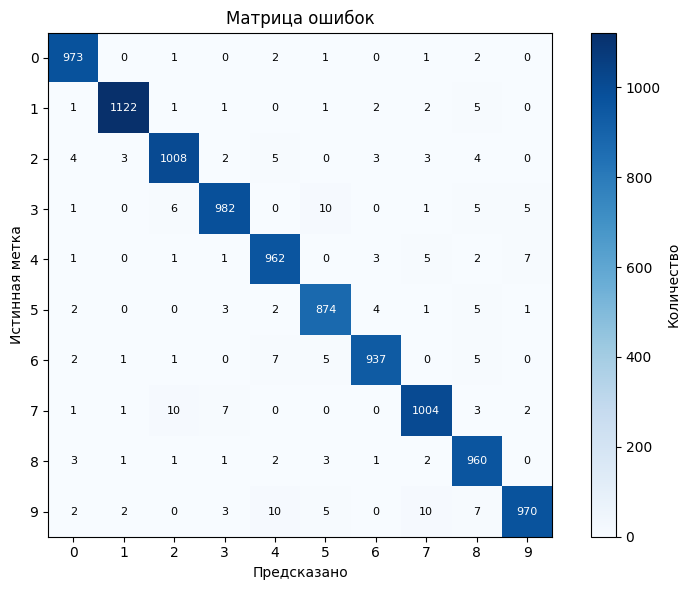

Топ-5 пар ошибок (истинная -> предсказана):
  9 -> 7: 10 раз
  9 -> 4: 10 раз
  7 -> 2: 10 раз
  3 -> 5: 10 раз
  9 -> 8: 7 раз


In [85]:
model.eval()
wrong_images = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())
        if len(wrong_images) >= 12:
            break

plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

# Матрица ошибок
all_true, all_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds  = model(images).argmax(dim=1)
        all_true.extend(labels.numpy())
        all_pred.extend(preds.cpu().numpy())
all_true = np.array(all_true)
all_pred = np.array(all_pred)
conf = np.zeros((10, 10), dtype=int)
for t, p in zip(all_true, all_pred):
    conf[t][p] += 1
plt.figure(figsize=(8, 6))
plt.imshow(conf, cmap="Blues")
plt.colorbar(label="Количество")
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel("Предсказано"); plt.ylabel("Истинная метка")
plt.title("Матрица ошибок")
for i in range(10):
    for j in range(10):
        plt.text(j, i, conf[i, j], ha="center", va="center",
                 color="white" if conf[i, j] > conf.max() * 0.5 else "black",
                 fontsize=8)
plt.tight_layout(); plt.show()

errors = [(conf[i][j], i, j) for i in range(10) for j in range(10) if i != j]
errors.sort(reverse=True)
print("Топ-5 пар ошибок (истинная -> предсказана):")
for cnt, true, pred in errors[:5]:
    print(f"  {true} -> {pred}: {cnt} раз")


### Краткий анализ ошибок (заполните сами)

Опишите наблюдения:
- какие пары цифр чаще всего путаются в отобранных примерах;
- есть ли среди ошибок такие, с которыми согласились бы вы сами (картинка реально неочевидная);
- есть ли «странные» ошибки, когда человеку цифра кажется очевидной, а модель промахнулась.


In [87]:
errors_comment = """
Топ-5 пар ошибок (истинная -> предсказана):
  9 -> 7: 10 раз
  9 -> 4: 10 раз
  7 -> 2: 10 раз
  3 -> 5: 10 раз
  9 -> 8: 7 раз
С ошибками с которыми я согласилась бы - это 3 -> 5 (верхняя дуга у них одинаковая), 
6 -> 0 (совсем не видно верхний хвостик шестерки), 2 -> 7 (тут просто небрежное написание и из-за короткого хвоста).
Странные ошибки: 2 -> 1, 8 -> 4. Для меня очевидно, что они разные, но модель почему-то решила, что они схожи.
Вывод: почти все ошибки визуально объяснимы, в основном модель ошибается там где картинка небрежная, но и нелепые ошибки тоже присутствуют.
"""
print(errors_comment)


Топ-5 пар ошибок (истинная -> предсказана):
  9 -> 7: 10 раз
  9 -> 4: 10 раз
  7 -> 2: 10 раз
  3 -> 5: 10 раз
  9 -> 8: 7 раз
С ошибками с которыми я согласилась бы - это 3 -> 5 (верхняя дуга у них одинаковая), 
6 -> 0 (совсем не видно верхний хвостик шестерки), 2 -> 7 (тут просто небрежное написание и из-за короткого хвоста).
Странные ошибки: 2 -> 1, 8 -> 4. Для меня очевидно, что они разные, но модель почему-то решила, что они схожи.
Вывод: почти все ошибки визуально объяснимы, в основном модель ошибается там где картинка небрежная, но и нелепые ошибки тоже присутствуют.



## 9. Итоговые выводы по лабораторной работе

Эта часть — ключевая для проверки понимания.  
Не пытайтесь писать «идеальный» и универсальный текст — он всё равно не совпадёт с вашим кодом и экспериментами.

Ответьте в свободной форме (примерно 10–15 предложений):
1. Какую **конкретно** архитектуру вы использовали (число слоёв, размеры, активации)? Пробовали ли вы другие варианты и что изменилось?
2. Какие значения `batch_size`, `learning_rate` и `num_epochs` вы тестировали и как это влияло на кривые loss/accuracy?
3. Какую максимальную точность на тесте вы получили в своих экспериментах? Считаете ли вы её удовлетворительной для такой модели?
4. Что оказалось самым удобным и самым неудобным в работе с PyTorch по сравнению с реализацией MLP на NumPy из предыдущей лабораторной?

Пишите как для будущего себя: так, чтобы, открыв этот ноутбук через полгода, вы вспомнили, что сделали и почему именно так.


In [90]:
final_text = """
1. Была использована архитектура 784->256->128->10, потому что простая и и так способна уловить нелинейные зависимости. 
Я не стала усложнять сеть, так как это бы увеличило время обучения и риск переобучения. ReLU оставила так, она не перенасащается в отличии от той же сигмоиды или tanh.
2. Пробовала разные значения learning_rate и num_epochs. Лучше всего сработало lr = 1e-3 и 5 эпох.
При lr = 1e-2 все три оптимизатора дали test_acc ниже 0.971, тогда как lr=1e-3 за те же 5 эпох выше 0.978. Если увеличть num_epochs больше 5, то точно почти не растет, а начинается переобучение.
batch_size оставила 64, менять не стала.
3. Максимальная точность получилась 0.98, считаю это хорошим результатом. Ниже 0.95 не опускалась ни в одном запуске.
4. В PyTorch что хорошо, что не надо писать градиенты, можно просто писать loss.backward(). Смущало, что были незнакомые функции, которые непонятно, что делают, нужно было часто искать, что происходит.
Раздражало, что 5 эпох на cpu занимало несколько минут, особенно когда делаешь много запусков подряд.
"""
print(final_text)


1. Была использована архитектура 784->256->128->10, потому что простая и и так способна уловить нелинейные зависимости. 
Я не стала усложнять сеть, так как это бы увеличило время обучения и риск переобучения. ReLU оставила так, она не перенасащается в отличии от той же сигмоиды или tanh.
2. Пробовала разные значения learning_rate и num_epochs. Лучше всего сработало lr = 1e-3 и 5 эпох.
При lr = 1e-2 все три оптимизатора дали test_acc ниже 0.971, тогда как lr=1e-3 за те же 5 эпох выше 0.978. Если увеличть num_epochs больше 5, то точно почти не растет, а начинается переобучение.
batch_size оставила 64, менять не стала.
3. Максимальная точность получилась 0.98, считаю это хорошим результатом. Ниже 0.95 не опускалась ни в одном запуске.
4. В PyTorch что хорошо, что не надо писать градиенты, можно просто писать loss.backward(). Смущало, что были незнакомые функции, которые непонятно, что делают, нужно было часто искать, что происходит.
Раздражало, что 5 эпох на cpu занимало несколько минут,